# Subcategory Analysis
## Project: Product Placement Optimisation
### Purpose: Define subcategories within 5 high volume categories and find which subcategories are bought together, adding a third level to the placement hierarchy
### Input: data/processed/sales_data_cleaned.csv
### Output: Subcategory transaction counts, within category association analysis and chart24_subcategory_analysis.png
## Student: Samikshya Baniya
## Student ID: 230360
## Module: ST6001CEM Individual Project

## Why Subcategory Analysis Matters

The project so far answers placement at two levels. Clustering (notebook 06) grouped the 25 categories into 3 store zones with a silhouette score of 0.554, and market basket analysis (notebook 05) found which categories should be placed near each other, with lift up to 6.81. Both results tell the owner where a category section belongs in the store, but not how to arrange the shelves inside that section.

This notebook adds the missing third level. Products inside 5 high volume categories are manually grouped into logical subcategories based on their product names, for example all dal products within FOOD STAPLES become a Pulses subcategory and sugar, jaggery and mishri become Sweeteners. Association analysis is then run within each category to find which subcategories share baskets, which tells the owner how to order shelves inside each category section.

The three levels of the placement hierarchy are:

1. **Zones** from clustering (notebook 06): which categories belong in the same area of the store
2. **Categories** from market basket analysis (notebook 05): which category sections should sit next to each other
3. **Subcategories** from this notebook: how shelves should be arranged inside each category section

## Step 1: Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from itertools import combinations
from mlxtend.frequent_patterns import apriori, association_rules

figures_path = r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\reports\figures'
os.makedirs(figures_path, exist_ok=True)

df = pd.read_csv(
    r'D:\softwarica\Sem 6\Individual Project\product-placement-optimization\data\processed\sales_data_cleaned.csv'
)

print("Data loaded successfully!")
print(f"Rows: {len(df):,}")
print(f"Transactions: {df['invoice_no'].nunique():,}")
print(f"Products with sales in the cleaned data: {df['product'].nunique():,} (of 5,681 in the raw data audit)")
print(f"Categories: {df['category'].nunique()}")

print("\nTop 6 categories by transaction count:")
cat_tx = df.groupby('category')['invoice_no'].nunique().sort_values(ascending=False)
print(cat_tx.head(6).to_string())

Data loaded successfully!
Rows: 767,180
Transactions: 218,037
Products with sales in the cleaned data: 5,680 (of 5,681 in the raw data audit)
Categories: 25

Top 6 categories by transaction count:
category
FOOD STAPLES                 91988
CANNED AND PACKAGED FOODS    62371
BISCUITS AND COOKIES         33209
TEA AND SPICES               32978
COOKING OIL                  32926
CLEANING SUPPLIES            30944


### Why These 5 Categories

The 5 categories analysed are FOOD STAPLES, CANNED AND PACKAGED FOODS, TEA AND SPICES, COOKING OIL and CLEANING SUPPLIES. They are 5 of the 6 busiest categories in the store. BISCUITS AND COOKIES ranks third with 33,209 transactions but is left out because its products are all variants of one product type (packet biscuits), so splitting it into subcategories would not produce meaningful shelf groups. The 5 selected categories each contain clearly different product types that map to separate shelves, which is exactly the situation subcategory analysis is designed for.

## Step 2: Define Subcategories

The store's billing system does not record subcategories, so they are defined manually with keyword rules applied to product names. Each category has an ordered list of subcategories with the keywords that identify them. The first matching subcategory wins, so the order matters: within FOOD STAPLES the Seasonings list (which contains DALCHINI, cinnamon) is checked before the Pulses list, otherwise the keyword DAL inside DALCHINI would wrongly classify cinnamon as a pulse. Products that match no keyword fall into an Other bucket, which is kept visible in every table so the coverage of the manual grouping is honest and checkable.

In [2]:
TOP5_CATEGORIES = ['FOOD STAPLES', 'CANNED AND PACKAGED FOODS', 'TEA AND SPICES',
                   'COOKING OIL', 'CLEANING SUPPLIES']

# Ordered keyword rules: the first matching subcategory wins.
SUBCATEGORY_KEYWORDS = {
    'FOOD STAPLES': [
        ('Grains and Flour',    ['RICE', 'CHAMAL', 'MAKAI', 'AATA', 'MAIDA', 'SUJI', 'PITHO',
                                 'BHUJA', 'CHIURA', 'CHAKKI', 'BASMATI', 'JEERA MASINO', 'DHAN']),
        ('Seasonings',          ['DALCHINI', 'SALT', 'NUN', 'JEERA', 'METHI', 'JWANO', 'TILL',
                                 'TIL ', 'SOFF', 'PANCHAPURAN', 'DHANIYA', 'TESTING', 'AJINOMOTO', 'MASALA']),
        ('Pulses',              ['DAL', 'DAAL', 'CHANA', 'CHAANA', 'KERAU', 'MONG', 'MASHURO',
                                 'BHATTA', 'BODI', 'RAHAR', 'SIMI']),
        ('Sweeteners',          ['SUGAR', 'SAKKHAR', 'GUD', 'JAGGERY', 'MISHRI', 'CHAKU', 'CHINI']),
        ('Dairy and Eggs',      ['MILK', 'EGG', 'DUDH', 'PANEER', 'GHIU']),
        ('Nuts and Dry Fruits', ['BADAM', 'MIXNUT', 'COCONUT', 'KAJU', 'OKHAR', 'KISMISS',
                                 'CASHEW', 'ALMOND']),
    ],
    'CANNED AND PACKAGED FOODS': [
        ('Noodles and Pasta',         ['CHOWMIN', 'RAMEN', 'RAMYAN', 'MACARONI', 'MACORONI', 'PASTA',
                                       'NOODLE', 'WAI WAI', 'WAIWAI', '2PM', '2 PM', 'SOUP',
                                       'SAMYANG', 'BULDAK']),
        ('Chips and Snacks',          ['LAYS', 'CHIPS', 'CHEESEBALL', 'CHEESE BALL', 'STICKS', 'BHUJA',
                                       'DALMOT', 'FURANDANA', 'KURKURE', 'CURRENT', 'CRAX', 'RINGS',
                                       'JHILINGA', 'PRAWN']),
        ('Papad and Fryums',          ['PAPAD', 'FRYUMS', 'FRYUM']),
        ('Dry Fruits and Nuts',       ['KAJU', 'ALMOND', 'OKHAR', 'KISMISS', 'MIXNUT', 'BADAM',
                                       'ANJEER', 'CHHOKADA', 'DATES']),
        ('Pickles and Sauces',        ['PICKLE', 'ACHAR', 'CHUK', 'SAUCE', 'KETCHUP', 'JAM ', 'HONEY',
                                       'TITAURA', 'VINEGAR', 'MAYONNAISE']),
        ('Health Drinks and Cereals', ['HORLICKS', 'BOURNVITA', 'VIVA', 'OATS', 'CORNFLAKES', 'MUESLI',
                                       'MUSELI', 'CEREAL', 'GLUCOSE', 'COMPLAN']),
        ('Beaten Rice and Flakes',    ['CHIURA', 'FLAKES']),
    ],
    'TEA AND SPICES': [
        ('Tea',                      ['TEA', 'CHIYA', 'TOKLA', 'SAIDEEP', 'SAI DEEP', 'MITTAL', 'SARBADA']),
        ('Coffee',                   ['NES', 'COFFEE', 'MAC ']),
        ('Masala Blends',            ['MASALA']),
        ('Whole Spices',             ['MARIJ', 'SUKMEL', 'LWANG', 'JEERA', 'TILL', 'JWANO', 'METHI',
                                      'SOFF', 'DALCHINI', 'TEJPAT', 'ALAICHI', 'BIRE']),
        ('Spice Powders and Flours', ['CHILLYPOW', 'TUMERIC', 'TURMERIC', 'BESHAN', 'PITHO', 'POWDER',
                                      'HALDI', 'KHURSANI']),
    ],
    'COOKING OIL': [
        ('Sunflower Oil',           ['SUNFLOWER', 'SUNFLOWEER', 'SUNFLOW', 'SUNF ', 'SUNBEAN SUN']),
        ('Mustard Oil',             ['MUSTARD', 'TORI']),
        ('Soybean Oil',             ['SOYABEAN', 'SOYBEAN']),
        ('Ghee and Vanaspati',      ['GHEE', 'DALDA', 'VANASPATI']),
        ('Blended and Health Oils', ['HEALTH', 'CORN', 'SAFFOLA', 'OLIVE', 'RICE BRAN']),
    ],
    'CLEANING SUPPLIES': [
        ('Detergent Powder',          ['RIN ', 'TIDE', 'ARIEL', 'WHEEL', 'SURF', 'XTRAA PLUS', 'HENKO',
                                       'DAZ ', 'DET ']),
        ('Washing Soap Bars',         ['SOAP', 'LUX', 'TIKA', 'DHONI', 'RICH', 'ZOOM', 'AAHA',
                                       'XTRAA NEEM', 'DTT', 'DETTOL', 'LIFEBUOY', 'LB ', 'LIRIL',
                                       'DOVE', 'SANTOOR', 'HANDWASH']),
        ('Dishwash',                  ['VIM', 'EXO', 'DISHWASH', 'PITAMBARI', 'SCOTCH', 'JUNA']),
        ('Toilet and Floor Cleaners', ['HRP', 'HARPIC', 'COLIN', 'LIZOL', 'LYS', 'PHENYL', 'TOILET',
                                       'FLOOR', 'ACID', 'BRUSH', 'BROOM', 'KUCHO', 'MOP']),
    ],
}

def assign_subcategory(product_name, category):
    name = str(product_name).upper()
    for subcat, keywords in SUBCATEGORY_KEYWORDS[category]:
        for kw in keywords:
            if kw in name:
                return subcat
    return 'Other'

top5_df = df[df['category'].isin(TOP5_CATEGORIES)].copy()

# Classify each unique (category, product) pair once, then merge back
unique_pairs = top5_df[['category', 'product']].drop_duplicates().copy()
unique_pairs['subcategory'] = unique_pairs.apply(
    lambda r: assign_subcategory(r['product'], r['category']), axis=1
)
top5_df = top5_df.merge(unique_pairs, on=['category', 'product'], how='left')

print(f"Rows in the 5 selected categories: {len(top5_df):,} of {len(df):,} ({len(top5_df)/len(df)*100:.1f}%)")
print()
for cat in TOP5_CATEGORIES:
    sub = top5_df[top5_df['category'] == cat]
    matched = sub[sub['subcategory'] != 'Other']['product'].nunique()
    total = sub['product'].nunique()
    n_sub = sub[sub['subcategory'] != 'Other']['subcategory'].nunique()
    print(f"{cat}: {total} products grouped into {n_sub} subcategories "
          f"({matched} products matched, {total - matched} in Other)")

Rows in the 5 selected categories: 411,228 of 767,180 (53.6%)

FOOD STAPLES: 439 products grouped into 6 subcategories (205 products matched, 234 in Other)
CANNED AND PACKAGED FOODS: 690 products grouped into 7 subcategories (304 products matched, 386 in Other)
TEA AND SPICES: 255 products grouped into 5 subcategories (220 products matched, 35 in Other)
COOKING OIL: 84 products grouped into 5 subcategories (82 products matched, 2 in Other)


CLEANING SUPPLIES: 346 products grouped into 4 subcategories (265 products matched, 81 in Other)


## Step 3: Transaction Counts per Subcategory

In [3]:
subcat_stats = {}
for cat in TOP5_CATEGORIES:
    sub = top5_df[top5_df['category'] == cat]
    total_tx = sub['invoice_no'].nunique()
    stats = sub.groupby('subcategory').agg(
        products=('product', 'nunique'),
        transactions=('invoice_no', 'nunique'),
    ).sort_values('transactions', ascending=False)
    stats['share_pct'] = (stats['transactions'] / total_tx * 100).round(1)
    subcat_stats[cat] = stats
    print("=" * 72)
    print(f"{cat}  ({total_tx:,} transactions)")
    print("=" * 72)
    print(stats.to_string())
    print()

FOOD STAPLES  (91,988 transactions)
                     products  transactions  share_pct
subcategory                                           
Pulses                     53         31798       34.6
Sweeteners                 14         24365       26.5
Grains and Flour           53         24219       26.3
Seasonings                 69         23093       25.1
Other                     234         19940       21.7
Dairy and Eggs              2         10170       11.1
Nuts and Dry Fruits        14          8266        9.0

CANNED AND PACKAGED FOODS  (62,371 transactions)
                           products  transactions  share_pct
subcategory                                                 
Other                           386         26810       43.0
Chips and Snacks                 70         16962       27.2
Noodles and Pasta                41         14029       22.5
Dry Fruits and Nuts              33          7069       11.3
Pickles and Sauces               99          6604    

### Finding: Subcategory Mix

Every category has one or two dominant subcategories that deserve the most shelf space. Within FOOD STAPLES (91,988 transactions) the biggest subcategories are Pulses (31,798 transactions, 34.6%), Sweeteners (24,365, 26.5%), Grains and Flour (24,219, 26.3%) and Seasonings (23,093, 25.1%). Within COOKING OIL, Sunflower Oil alone appears in 17,808 of 32,926 transactions (54.1%), three times the size of Mustard Oil (6,187, 18.8%). Within CLEANING SUPPLIES, Washing Soap Bars appear in 20,789 of 30,944 transactions (67.2%), so soap bars should get the largest and most reachable shelf in that section. The Other bucket stays visible in every table: it is largest in CANNED AND PACKAGED FOODS (26,810 transactions, 43.0%) because that category contains 690 very varied products, and smallest in TEA AND SPICES (7.4%).

## Step 4: Which Subcategories Are Bought Together

For each category, a basket matrix is built with one row per transaction that contains at least one named subcategory of that category, and one column per subcategory. The Other bucket is excluded because a shelf cannot be arranged around an unnamed group. Pair counts show which subcategories share baskets most often, and the same mlxtend apriori and association_rules method as notebook 05 is used as a cross check on lift.

In [4]:
pair_tables = {}
for cat in TOP5_CATEGORIES:
    sub = top5_df[top5_df['category'] == cat]
    named = sub[sub['subcategory'] != 'Other']
    basket = named.groupby(['invoice_no', 'subcategory']).size().unstack(fill_value=0) > 0

    rows = []
    for a, b in combinations(sorted(basket.columns), 2):
        both = int((basket[a] & basket[b]).sum())
        support = both / len(basket)
        lift = support / (basket[a].mean() * basket[b].mean())
        rows.append({'subcategory_a': a, 'subcategory_b': b,
                     'baskets_together': both,
                     'support': round(support, 4), 'lift': round(lift, 2)})
    pairs = pd.DataFrame(rows).sort_values('baskets_together', ascending=False).reset_index(drop=True)
    pair_tables[cat] = pairs

    print("=" * 72)
    print(f"{cat}: {len(basket):,} baskets contain a named subcategory")
    print("=" * 72)
    print(pairs.head(3).to_string(index=False))

    # Cross check with the same mlxtend method used in notebook 05
    freq = apriori(basket, min_support=0.01, use_colnames=True)
    rules = association_rules(freq, metric='support', min_threshold=0.01)
    rules = rules[(rules['antecedents'].apply(len) == 1) & (rules['consequents'].apply(len) == 1)]
    if len(rules):
        best = rules.sort_values('lift', ascending=False).iloc[0]
        a = list(best['antecedents'])[0]
        b = list(best['consequents'])[0]
        print(f"mlxtend cross check, highest lift rule: {a} -> {b} "
              f"(lift {best['lift']:.2f}, confidence {best['confidence']:.2f})")
    print()

FOOD STAPLES: 83,134 baskets contain a named subcategory
   subcategory_a subcategory_b  baskets_together  support  lift
          Pulses    Sweeteners              8300   0.0998  0.89
          Pulses    Seasonings              8143   0.0980  0.92
Grains and Flour        Pulses              7252   0.0872  0.78
mlxtend cross check, highest lift rule: Pulses -> Seasonings (lift 0.92, confidence 0.26)

CANNED AND PACKAGED FOODS: 45,318 baskets contain a named subcategory
    subcategory_a      subcategory_b  baskets_together  support  lift
 Chips and Snacks   Papad and Fryums              2428   0.0536  1.12
 Chips and Snacks  Noodles and Pasta              2403   0.0530  0.46
Noodles and Pasta Pickles and Sauces              1265   0.0279  0.62
mlxtend cross check, highest lift rule: Papad and Fryums -> Chips and Snacks (lift 1.12, confidence 0.42)

TEA AND SPICES: 31,529 baskets contain a named subcategory
subcategory_a            subcategory_b  baskets_together  support  lift
Masala B

CLEANING SUPPLIES: 29,703 baskets contain a named subcategory
            subcategory_a     subcategory_b  baskets_together  support  lift
         Detergent Powder Washing Soap Bars              4452   0.1499  0.63
                 Dishwash Washing Soap Bars              1795   0.0604  0.66
Toilet and Floor Cleaners Washing Soap Bars              1152   0.0388  0.55
mlxtend cross check, highest lift rule: Washing Soap Bars -> Dishwash (lift 0.66, confidence 0.09)



### Finding: Substitutes Inside a Category, Complements Between Categories

The lift values inside a category behave very differently from the category level results in notebook 05, and this is the most important lesson of this notebook. At category level the maximum lift was 6.81 because different categories complement each other. Within a single category most subcategory pairs have lift below 1.0, for example Mustard Oil with Sunflower Oil at lift 0.33, because subcategories of the same category often substitute for each other: a household picks one type of cooking oil per trip, not several.

There are two clear positive exceptions. Ghee and Vanaspati with Soybean Oil has lift 1.45 (19.5% of ghee baskets also contain soybean oil), which makes sense because vanaspati ghee is used for specific dishes alongside a regular frying oil. Chips and Snacks with Papad and Fryums has lift 1.12, and 41.9% of papad baskets also contain chips and snacks, so both snacking groups belong side by side.

Because within category lift is mostly below 1.0, shelf arrangement inside a section should be driven by shared basket volume, not lift alone. The pairs with the most shared baskets are: Pulses with Sweeteners in FOOD STAPLES (8,300 baskets), Detergent Powder with Washing Soap Bars in CLEANING SUPPLIES (4,452 baskets, 44.4% of detergent baskets also contain soap bars), Chips and Snacks with Papad and Fryums in CANNED AND PACKAGED FOODS (2,428 baskets), Masala Blends with Spice Powders and Flours in TEA AND SPICES (1,578 baskets) and Mustard Oil with Sunflower Oil in COOKING OIL (1,199 baskets). Placing these pairs on adjacent shelves puts the second item in front of the customer who is already standing there.

## Step 5: Summary Table Across All 5 Categories

In [5]:
summary_rows = []
for cat in TOP5_CATEGORIES:
    stats = subcat_stats[cat]
    pairs = pair_tables[cat]
    for subcat, row in stats.iterrows():
        if subcat == 'Other':
            partner, shared = '-', '-'
        else:
            mask = (pairs['subcategory_a'] == subcat) | (pairs['subcategory_b'] == subcat)
            best = pairs[mask].iloc[0]
            partner = best['subcategory_b'] if best['subcategory_a'] == subcat else best['subcategory_a']
            shared = f"{best['baskets_together']:,}"
        summary_rows.append({
            'category': cat,
            'subcategory': subcat,
            'products': row['products'],
            'transactions': row['transactions'],
            'share_pct': row['share_pct'],
            'top_partner_subcategory': partner,
            'shared_baskets': shared,
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

named_total = (summary_df['subcategory'] != 'Other').sum()
print(f"\nNamed subcategories defined across the 5 categories: {named_total}")

                 category               subcategory  products  transactions  share_pct  top_partner_subcategory shared_baskets
             FOOD STAPLES                    Pulses      53.0       31798.0       34.6               Sweeteners          8,300
             FOOD STAPLES                Sweeteners      14.0       24365.0       26.5                   Pulses          8,300
             FOOD STAPLES          Grains and Flour      53.0       24219.0       26.3                   Pulses          7,252
             FOOD STAPLES                Seasonings      69.0       23093.0       25.1                   Pulses          8,143
             FOOD STAPLES                     Other     234.0       19940.0       21.7                        -              -
             FOOD STAPLES            Dairy and Eggs       2.0       10170.0       11.1                   Pulses          1,296
             FOOD STAPLES       Nuts and Dry Fruits      14.0        8266.0        9.0                   Pulses

## Step 6: Chart 24, Subcategory Transaction Counts

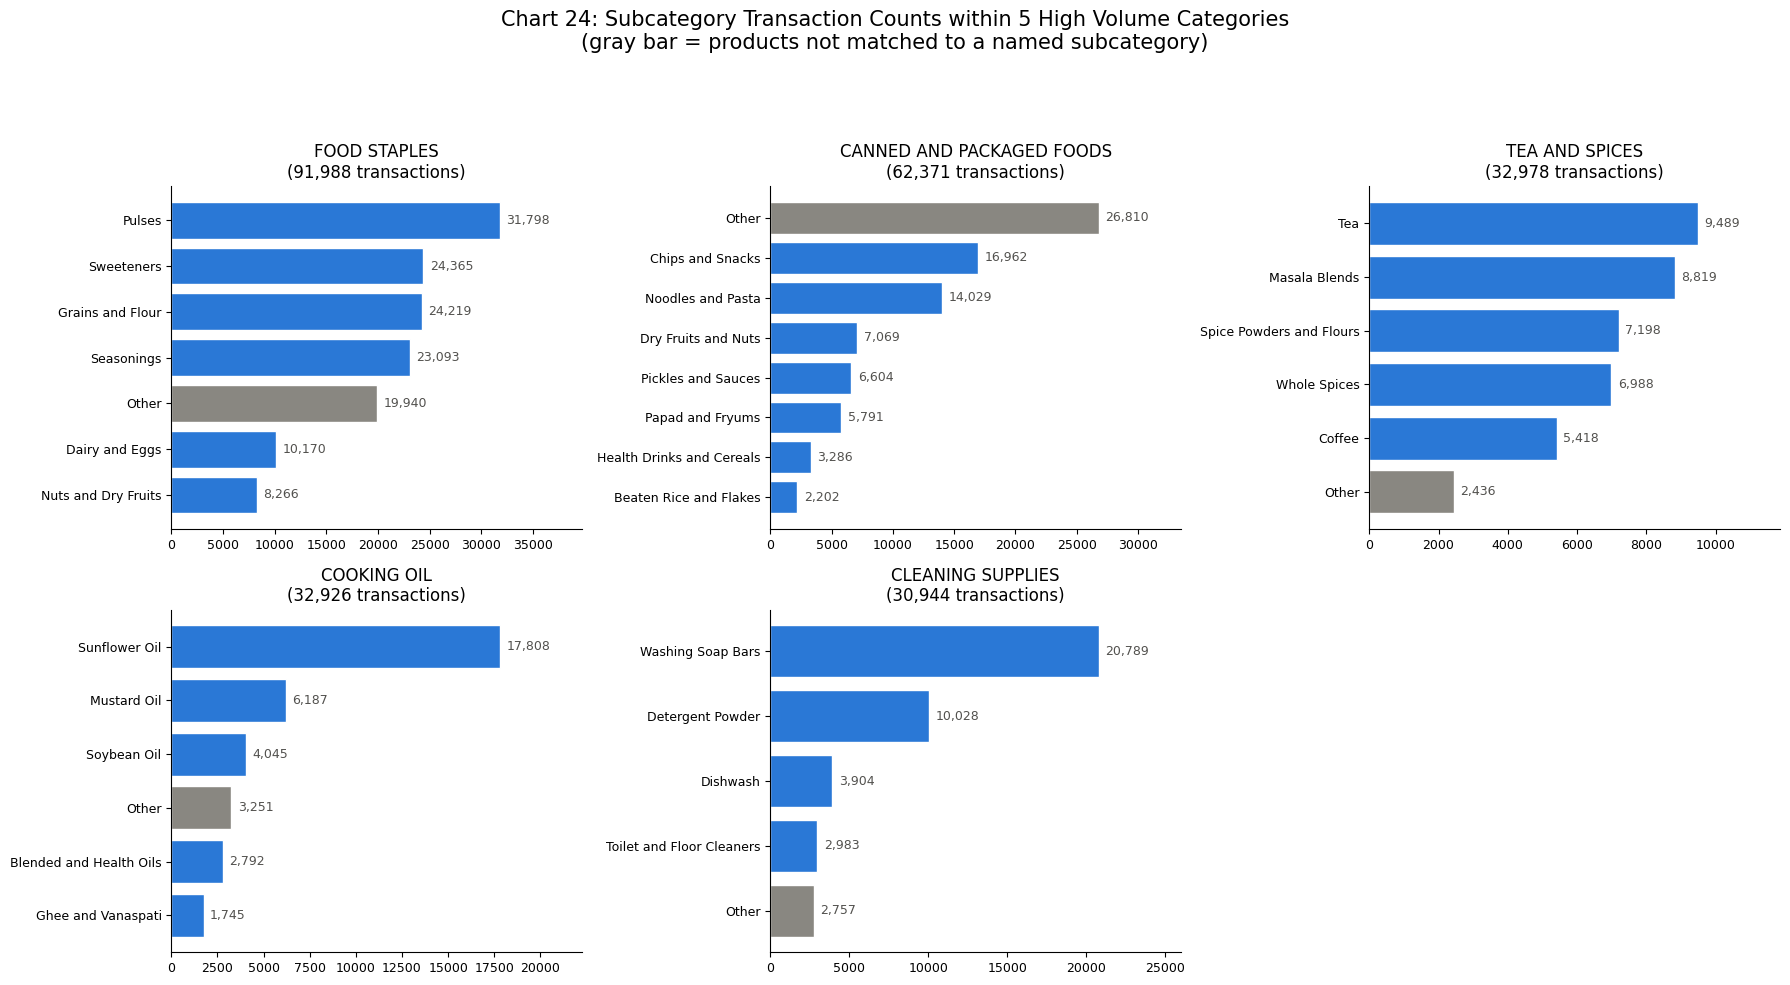

Chart 24 saved!


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
BAR_COLOR = '#2a78d6'
OTHER_COLOR = '#898781'

for i, cat in enumerate(TOP5_CATEGORIES):
    ax = axes[i]
    counts = subcat_stats[cat]['transactions'].sort_values()
    colors = [OTHER_COLOR if s == 'Other' else BAR_COLOR for s in counts.index]
    ax.barh(list(counts.index), counts.values, color=colors, edgecolor='white')
    for j, v in enumerate(counts.values):
        ax.text(v + counts.max() * 0.02, j, f'{v:,}', va='center', fontsize=9, color='#52514e')
    total_tx = top5_df[top5_df['category'] == cat]['invoice_no'].nunique()
    ax.set_title(f'{cat}\n({total_tx:,} transactions)', fontsize=12)
    ax.set_xlim(0, counts.max() * 1.25)
    ax.tick_params(labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[5].axis('off')
fig.suptitle('Chart 24: Subcategory Transaction Counts within 5 High Volume Categories\n'
             '(gray bar = products not matched to a named subcategory)', fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(figures_path, 'chart24_subcategory_analysis.png'), dpi=150)
plt.show()
print("Chart 24 saved!")

### Finding: The Complete Three Level Placement Hierarchy

Subcategory analysis completes the placement hierarchy that this project builds for Baniya Shopping Center. Each level answers a different question at a different physical scale of the store:

1. **Zones** (notebook 06, clustering): which categories belong in the same area of the store. Co-occurrence clustering found 3 zones with a silhouette score of 0.554.
2. **Categories** (notebook 05, market basket analysis): which category sections should sit next to each other inside a zone. 1,228 association rules were found with a maximum lift of 6.81, and 1,226 of them are statistically significant at p below 0.05.
3. **Subcategories** (this notebook): how shelves should be ordered inside each category section. 27 named subcategories were defined across 5 high volume categories, and shared basket counts identify which shelves belong side by side, for example Pulses next to Sweeteners and Seasonings inside the FOOD STAPLES section (8,300 and 8,143 shared baskets).

For the store owner this turns into one concrete instruction per level: put the right categories in the right zone, put related category sections next to each other, and inside each section put the subcategory shelves that share the most baskets within arm's reach of each other. The subcategory level also revealed something the category level could not: products within a category often substitute for each other (most within category lifts are below 1.0), so the goal inside a section is convenient comparison, while the goal between sections is prompting the complementary purchase.